In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(3,3,0), "ZZ", ""),
    (Position3DHex(2,2,0), "ZN", ""),
    (Position3DHex(1,3,0), "ZZ", ""),

    (Position3DHex(3,3,1), "XX", ""),
    (Position3DHex(2,2,1), "NX", ""),
    (Position3DHex(1,3,1), "XX", ""),    

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[2][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[3][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[5][0], prisms[4][0], pipe_kind)

In [3]:
g.view_as_html()

In [4]:
zx = g.to_zx_graph()
correlation_surfaces = g.find_correlation_surfaces()
print("len correlation surfaces", len(correlation_surfaces))


from tqec.computation.correlation import (
    CorrelationSurface,
    ZXEdge,
    ZXNode,
)
from tqec.utils.enums import Basis

#!ZX is not correctly assigned if no additional input possible for spatial ports
cs = CorrelationSurface(
    frozenset({
        ZXEdge(
            ZXNode(3, Basis.X),
            ZXNode(4, Basis.X),
        ),
        ZXEdge(
            ZXNode(4, Basis.X),
            ZXNode(5, Basis.X),
        ),
        ZXEdge(
            ZXNode(4, Basis.X),
            ZXNode(1, Basis.X),
        ),
        ZXEdge(
            ZXNode(2, Basis.X),
            ZXNode(1, Basis.X),
        ),
    })
)

len correlation surfaces 0


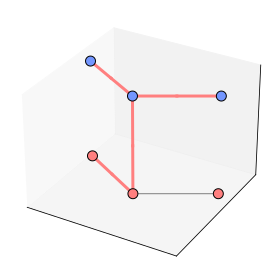

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


stabilizer tests passed
stabilizer tests passed


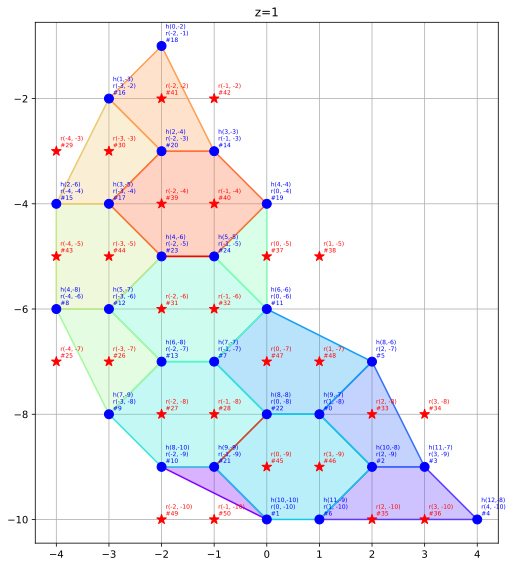

In [6]:
d=3
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 1
temp_utils.plot_mapping_full(mapping_full, z_temp)

In [8]:
d=3
rounds = d
p = 0.00


SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = [cs]
)

stabilizer tests passed
stabilizer tests passed
========================z=0=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=10, y=-8, z=0), rect=(2, -9), label=2), PositionEntry(hex=Position3DHex(x=11, y=-7, z=0), rect=(3, -9), label=3)]
lst [2, 33]
lst [3, 34]
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=10, y=-10, z=0), rect=(0, -10), label=1), PositionEntry(hex=Position3DHex(x=11, y=-9, z=0), rect=(1, -10), label=6)]
lst [1, 45]
lst [6, 46]
stab type X, >2 [11, 7, 22, 5, 0]
stab type X, >2 [10, 21, 1]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=7, y=-9, z=0), rect=(-3, -8), label=9)]
lst [9, 26]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=8, y=-10, z=0), rect=(-2, -9), label=10), PositionEntry(hex=Position3DHex(x=9, y=-9, z=0), rect=(-1, -9), label=21)]
lst [10, 27]
lst [21, 28]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=-8, z=0), rect

In [9]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_CNOT_spatial_d{d}.svg", "w") as f:
    f.write(str(svg))

In [10]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
Detectors that fired: []


In [11]:
dem = circuit.detector_error_model()
import stim

for instruction in dem.flattened():
    if instruction.type == "error":
        detectors = [t for t in instruction.targets_copy() 
                     if t.is_relative_detector_id()]
        logicals = [t for t in instruction.targets_copy() 
                    if t.is_logical_observable_id()]
        
        if len(detectors) == 0:
            print(f"Undetected error (p={instruction.args_copy()[0]}):")
            print(f"  Flips observables: {logicals}")
            print(f"  Full instruction: {instruction}")
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)

detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}, {[el-circuit.num_measurements for el in d]}")

ValueError: The circuit contains non-deterministic observables.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['L0', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords L0 > output_image.svg

This was discovered while analyzing a Z-basis reset (R) on:
    qubit 12 [coords (1, 4)]

The collapse anti-commuted with these detectors/observables:
    L0

The backward-propagating error sensitivity for L0 was:
    X7 [coords (3, 3)]
    X9 [coords (1, 2)]
    X12 [coords (1, 4)]

Circuit stack trace:
    during TICK layer #1 of 63
    at instruction #54 [which is R 7 8 9 10 11 12 13]

In [12]:
rec_to_label = {
    info.abs_rec: info.label
    for info in SE.meas_rec_lst
}

rec_to_info = {
    info.abs_rec: info
    for info in SE.meas_rec_lst
}

for abs_rec in d:
    print(abs_rec)
    info = rec_to_info[abs_rec+1]
    print(info.label)
    print(info.meas_type)
    print("----")

TypeError: 'int' object is not iterable

In [13]:
len(circuit.shortest_graphlike_error())

ValueError: The circuit contains non-deterministic observables.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['L0', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords L0 > output_image.svg

This was discovered while analyzing a Z-basis reset (R) on:
    qubit 12 [coords (1, 4)]

The collapse anti-commuted with these detectors/observables:
    L0

The backward-propagating error sensitivity for L0 was:
    X7 [coords (3, 3)]
    X9 [coords (1, 2)]
    X12 [coords (1, 4)]

Circuit stack trace:
    during TICK layer #1 of 63
    at instruction #54 [which is R 7 8 9 10 11 12 13]

## Is there a dependency of the geometrical alignment for the circuit level distance?

In the CNOT gate from /mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/syndrome_extraction_test_CNOT_260528.ipynb it appears to have full distance sometimes even if there is a vertical correlation surface taken into account. Let's check the distances for the 3 different alignments of a simple teleportation procedure

In [14]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [15]:
def summarize_errors(errors, canonical_only=True):
    """Compact, human-readable summary of a list of stim.ExplainedError."""
    for i, e in enumerate(errors):
        terms = []
        for term in e.dem_error_terms:
            t = term.dem_target
            coords = term.coords
            terms.append(f"{t}[{','.join(str(c) for c in coords)}]")
        print(f"Error {i}: flips {' '.join(terms)}")

        locs = e.circuit_error_locations
        if canonical_only:
            locs = locs[:1]

        for loc in locs:
            paulis = []
            for gt in loc.flipped_pauli_product:
                pauli = gt.gate_target
                if pauli.is_x_target:
                    p = "X"
                elif pauli.is_y_target:
                    p = "Y"
                elif pauli.is_z_target:
                    p = "Z"
                else:
                    p = "?"
                q = pauli.value  # integer qubit label
                coords = gt.coords
                paulis.append(f"{p} on qubit {q} @({','.join(str(c) for c in coords)})")

            instr = loc.instruction_targets
            print(
                f"    {' * '.join(paulis)}"
                f"  | tick {loc.tick_offset}, instruction {instr.gate}"
                f" (args={instr.args})"
            )
        print()

In [16]:
def get_observable_qubits(circuit, obs_index=0):
    """Return the list of qubit indices whose measurements contribute to
    OBSERVABLE_INCLUDE(obs_index), in order of appearance.
    """
    meas_targets = []  # list of qubit indices, one per measurement, in chronological order
    total_meas = 0
    obs_qubits = []

    for instr in circuit.flattened():
        if instr.name in ("M", "MX", "MY", "MZ", "MR", "MRX", "MRY", "MRZ"):
            for t in instr.targets_copy():
                if t.is_qubit_target:
                    meas_targets.append(t.value)
                    total_meas += 1
        elif instr.name == "OBSERVABLE_INCLUDE":
            if instr.gate_args_copy()[0] == obs_index:
                for t in instr.targets_copy():
                    if t.is_measurement_record_target:
                        rec_idx = t.value  # negative offset
                        abs_idx = total_meas + rec_idx
                        obs_qubits.append(meas_targets[abs_idx])

    return obs_qubits

In [17]:
ga = PrismGraph("two-patches-A")

prisms = [
    (Position3DHex(0,0,-1), "ZN", "init"),
    (Position3DHex(0,0,0), "NX", "left"),
    (Position3DHex(1,1,0), "XN", "right"),
    (Position3DHex(1,1,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    ga.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
ga.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
ga.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
ga.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

ga.view_as_html()

In [18]:
gb = PrismGraph("two-patches-B")

prisms = [
    (Position3DHex(2,2,-1), "ZN", "init"),
    (Position3DHex(2,2,0), "NX", "left"),
    (Position3DHex(1,3,0), "XN", "right"),
    (Position3DHex(1,3,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    gb.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
gb.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
gb.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
gb.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

gb.view_as_html()

In [19]:
gc = PrismGraph("two-patches-B")

prisms = [
    (Position3DHex(2,2,-1), "ZN", "init"),
    (Position3DHex(2,2,0), "NX", "left"),
    (Position3DHex(3,1,0), "XN", "right"),
    (Position3DHex(3,1,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    gc.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
gc.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
gc.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
gc.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

gc.view_as_html()

stabilizer tests passed


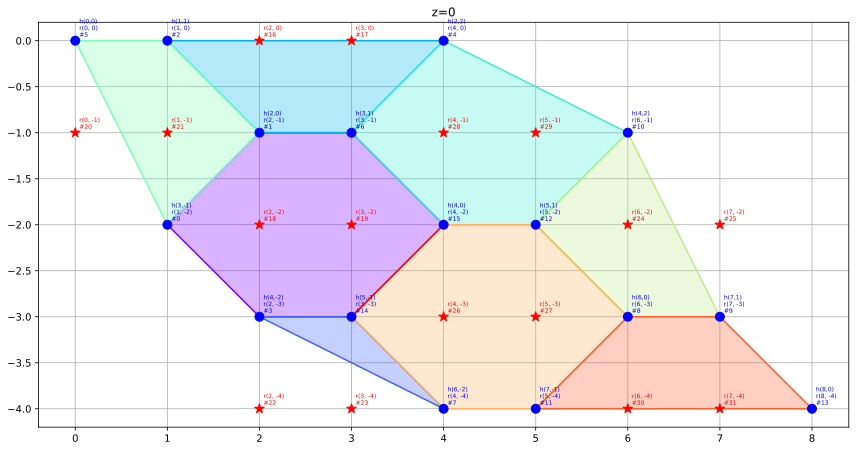

In [20]:
d=3
SE = se.SyndromeExtractionStimCC(ga, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 0
temp_utils.plot_mapping_full(mapping_full, z_temp)

In [22]:
d=5
rounds = d
p = 0.01

idx = 0
correlation_surfaces = ga.find_correlation_surfaces()
cs = correlation_surfaces[idx]

SE = se.SyndromeExtractionStimCC(ga, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = [cs]
)

dem = circuit.detector_error_model()


error = circuit.shortest_graphlike_error()
print(len(error))
errors = circuit.search_for_undetectable_logical_errors(
    dont_explore_detection_event_sets_with_size_above=d,
    dont_explore_edges_with_degree_above=2,
    dont_explore_edges_increasing_symptom_degree=True,
)
d = len(errors)
print(d)

summarize_errors(errors)

print(get_observable_qubits(circuit, 0))

stabilizer tests passed
========================z=-1=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=2, z=0), rect=(6, -1), label=1), PositionEntry(hex=Position3DHex(x=5, y=3, z=0), rect=(7, -1), label=12)]
lst [1, 42]
lst [12, 43]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=7, y=-3, z=0), rect=(3, -5), label=5)]
lst [5, 45]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=-2, z=0), rect=(2, -3), label=15), PositionEntry(hex=Position3DHex(x=5, y=-1, z=0), rect=(3, -3), label=16)]
lst [15, 46]
lst [16, 47]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=-2, z=0), rect=(4, -4), label=13), PositionEntry(hex=Position3DHex(x=7, y=-1, z=0), rect=(5, -4), label=10)]
lst [13, 48]
lst [10, 49]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=8, y=-4, z=0), rect=(4, -6), label=3)]
lst [3, 50]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=0, z=0), rect=(4, -2), 

In [23]:
fig = circuit.diagram("timeline-svg", tick=56)
with open(f"temp_A_d{d}.svg", "w") as f:
    f.write(str(fig))

In [24]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_tele_A_d{d}.svg", "w") as f:
    f.write(str(svg))

In [25]:
print(circuit.to_crumble_url())

https://algassert.com/crumble#circuit=Q(4,5)0;Q(6,6)1;Q(8,7)2;Q(4,1)3;Q(0,7)4;Q(3,2)5;Q(2,6)6;Q(4,7)7;Q(3,6)8;Q(5,7)9;Q(5,3)10;Q(5,5)11;Q(7,6)12;Q(4,3)13;Q(6,4)14;Q(2,4)15;Q(3,4)16;Q(1,5)17;Q(1,7)18;Q(12,3)19;Q(11,0)20;Q(10,6)21;Q(9,3)22;Q(11,4)23;Q(7,0)24;Q(11,2)25;Q(10,0)26;Q(12,1)27;Q(6,0)28;Q(9,5)29;Q(14,0)30;Q(13,1)31;Q(8,3)32;Q(7,2)33;Q(9,1)34;Q(10,2)35;Q(8,1)36;Q(10,4)37;Q(7,4)38;Q(6,2)39;Q(5,1)40;Q(8,5)41;Q(6,7)42;Q(7,7)43;Q(2,3)44;Q(3,3)45;Q(2,5)46;Q(3,5)47;Q(4,4)48;Q(5,4)49;Q(4,2)50;Q(5,2)51;Q(4,6)52;Q(5,6)53;Q(6,5)54;Q(7,5)55;Q(2,7)56;Q(3,7)57;Q(0,6)58;Q(1,6)59;Q(6,1)60;Q(7,1)61;Q(4,0)62;Q(5,0)63;Q(10,5)64;Q(11,5)65;Q(12,2)66;Q(13,2)67;Q(12,0)68;Q(13,0)69;Q(8,6)70;Q(9,6)71;Q(10,1)72;Q(11,1)73;Q(8,4)74;Q(9,4)75;Q(8,2)76;Q(9,2)77;Q(8,0)78;Q(9,0)79;Q(10,3)80;Q(11,3)81;Q(6,3)82;Q(7,3)83;R_0_1_2_3_4_5_6_7_8_9_10_11_12_13_14_15_16_17_18;X_ERROR(0.01)0_1_2_3_4_5_6_7_8_9_10_11_12_13_14_15_16_17_18;RX_42;Z_ERROR(0.01)42;R_43;X_ERROR(0.01)43;RX_44;Z_ERROR(0.01)44;R_45;X_ERROR(0.01)45;

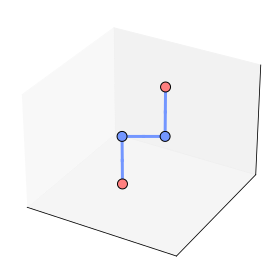

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

zx = ga.to_zx_graph()

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


stabilizer tests passed


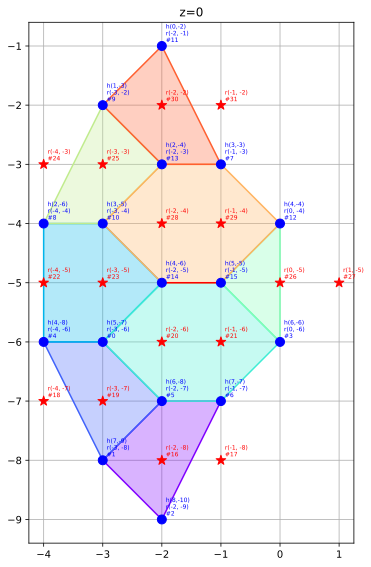

In [27]:
d=3
SE = se.SyndromeExtractionStimCC(gb, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 0
temp_utils.plot_mapping_full(mapping_full, z_temp)

In [28]:
d=3
rounds = d
p = 0.00

idx = 0
correlation_surfaces = gb.find_correlation_surfaces()
cs = correlation_surfaces[idx]

SE = se.SyndromeExtractionStimCC(gb, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = [cs]
)

dem = circuit.detector_error_model()


#!RUN MORE EXPENSIVE ERROR ESTIMATE
#error = circuit.shortest_graphlike_error()
#print(len(error))
#errors = circuit.search_for_undetectable_logical_errors(
#    dont_explore_detection_event_sets_with_size_above=d,
#    dont_explore_edges_with_degree_above=10,
#    dont_explore_edges_increasing_symptom_degree=False,
#    canonicalize_circuit_errors=True
#)
#d = len(errors)
#print(d)

#summarize_errors(errors)

stabilizer tests passed
========================z=-1=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=8, y=-10, z=0), rect=(-2, -9), label=2)]
lst [2, 16]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=7, y=-9, z=0), rect=(-3, -8), label=1)]
lst [1, 19]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=-8, z=0), rect=(-2, -7), label=5), PositionEntry(hex=Position3DHex(x=7, y=-7, z=0), rect=(-1, -7), label=6)]
lst [5, 20]
lst [6, 21]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=7, y=-9, z=0), rect=(-3, -8), label=1)]
lst [1, 16]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=-8, z=0), rect=(-2, -7), label=5)]
lst [5, 19]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=5, y=-7, z=0), rect=(-3, -6), label=0), PositionEntry(hex=Position3DHex(x=6, y=-6, z=0), rect=(0, -6), label=3)]
lst [0, 20]
lst [3, 21]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x

ValueError: The circuit contains non-deterministic observables.
The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(25, 35), filter_coords=['D19', 'D60', 'L0', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 25:35 --filter_coords D19:D60:L0 > output_image.svg

This was discovered while analyzing an X-basis reset (RX) on:
    qubit 13 [coords (2, 6)]

The collapse anti-commuted with these detectors/observables:
    D19
    D60
    L0

The backward-propagating error sensitivity for D19 was:
    Z7 [coords (3, 6)]
    Z10 [coords (1, 5)]
    Z12 [coords (4, 5)]
    Z13 [coords (2, 6)]

The backward-propagating error sensitivity for D60 was:
    Z0 [coords (1, 3)]
    Z3 [coords (4, 3)]
    Z5 [coords (2, 2)]
    Z6 [coords (3, 2)]
    Z7 [coords (3, 6)]
    Z10 [coords (1, 5)]
    Z12

In [29]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_tele_B_d{d}.svg", "w") as f:
    f.write(str(svg))

In [30]:
print(circuit.to_crumble_url())

https://algassert.com/crumble#circuit=Q(1,3)0;Q(1,1)1;Q(2,0)2;Q(4,3)3;Q(0,3)4;Q(2,2)5;Q(3,2)6;Q(3,6)7;Q(0,5)8;Q(1,7)9;Q(1,5)10;Q(2,8)11;Q(4,5)12;Q(2,6)13;Q(2,4)14;Q(3,4)15;Q(2,1)16;Q(3,1)17;Q(0,2)18;Q(1,2)19;Q(2,3)20;Q(3,3)21;Q(0,4)22;Q(1,4)23;Q(0,6)24;Q(1,6)25;Q(4,4)26;Q(5,4)27;Q(2,5)28;Q(3,5)29;Q(2,7)30;Q(3,7)31;R_0_1_2_3_4_5_6;X_ERROR(0)0_1_2_3_4_5_6;RX_16;Z_ERROR(0)16;R_17;X_ERROR(0)17;RX_18;Z_ERROR(0)18;R_19;X_ERROR(0)19;RX_20;Z_ERROR(0)20;R_21;X_ERROR(0)21;TICK;CX_16_17;DEPOLARIZE2(0)16_17;CX_18_19;DEPOLARIZE2(0)18_19;CX_20_21;DEPOLARIZE2(0)20_21;DEPOLARIZE1(0)0_1_2_3_4_5_6;TICK;CX_2_16;DEPOLARIZE2(0)2_16;CX_1_19;DEPOLARIZE2(0)1_19;CX_5_20;DEPOLARIZE2(0)5_20;CX_6_21;DEPOLARIZE2(0)6_21;DEPOLARIZE1(0)0_3_4_17_18;TICK;CX_1_16;DEPOLARIZE2(0)1_16;CX_5_19;DEPOLARIZE2(0)5_19;CX_0_20;DEPOLARIZE2(0)0_20;CX_3_21;DEPOLARIZE2(0)3_21;DEPOLARIZE1(0)2_4_6_17_18;TICK;CX_5_16;DEPOLARIZE2(0)5_16;CX_6_17;DEPOLARIZE2(0)6_17;CX_4_18;DEPOLARIZE2(0)4_18;CX_0_19;DEPOLARIZE2(0)0_19;DEPOLARIZE1(0)1_2_3_20

In [31]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? True
Detectors that fired: [19 60]
  D19: fired in 48/100 shots
  D60: fired in 48/100 shots


In [32]:
import stim
circuit_a = stim.Circuit('''
    QUBIT_COORDS(1, 3) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(4, 3) 3
    QUBIT_COORDS(0, 3) 4
    QUBIT_COORDS(2, 2) 5
    QUBIT_COORDS(3, 2) 6
    QUBIT_COORDS(3, 6) 7
    QUBIT_COORDS(0, 5) 8
    QUBIT_COORDS(1, 7) 9
    QUBIT_COORDS(1, 5) 10
    QUBIT_COORDS(2, 8) 11
    QUBIT_COORDS(4, 5) 12
    QUBIT_COORDS(2, 6) 13
    QUBIT_COORDS(2, 4) 14
    QUBIT_COORDS(3, 4) 15
    QUBIT_COORDS(2, 1) 16
    QUBIT_COORDS(3, 1) 17
    QUBIT_COORDS(0, 2) 18
    QUBIT_COORDS(1, 2) 19
    QUBIT_COORDS(2, 3) 20
    QUBIT_COORDS(3, 3) 21
    QUBIT_COORDS(0, 4) 22
    QUBIT_COORDS(1, 4) 23
    QUBIT_COORDS(0, 6) 24
    QUBIT_COORDS(1, 6) 25
    QUBIT_COORDS(4, 4) 26
    QUBIT_COORDS(5, 4) 27
    QUBIT_COORDS(2, 5) 28
    QUBIT_COORDS(3, 5) 29
    QUBIT_COORDS(2, 7) 30
    QUBIT_COORDS(3, 7) 31
    R 0 1 2 3 4 5 6
    X_ERROR(0) 0 1 2 3 4 5 6
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    DETECTOR rec[-5]
    DETECTOR rec[-3]
    DETECTOR rec[-1]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    CX rec[-5] 6 rec[-3] 0 rec[-3] 5 rec[-3] 1 rec[-1] 3 rec[-1] 6
    DEPOLARIZE1(0) 2 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    CX rec[-5] 6 rec[-3] 0 rec[-3] 5 rec[-3] 1 rec[-1] 3 rec[-1] 6
    DEPOLARIZE1(0) 2 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    CX rec[-5] 6 rec[-3] 0 rec[-3] 5 rec[-3] 1 rec[-1] 3 rec[-1] 6
    DEPOLARIZE1(0) 2 4
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    R 7 8 9 10 11 12 13
    X_ERROR(0) 7 8 9 10 11 12 13
    R 14 15
    X_ERROR(0) 14 15
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 22
    Z_ERROR(0) 22
    R 23
    X_ERROR(0) 23
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    RX 26
    Z_ERROR(0) 26
    R 27
    X_ERROR(0) 27
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    CX 14 28
    DEPOLARIZE2(0) 14 28
    CX 15 29
    DEPOLARIZE2(0) 15 29
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    DEPOLARIZE1(0) 0 3 4 9 11 12 17 18 22 23 26 27
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    CX 13 25
    DEPOLARIZE2(0) 13 25
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 9 30
    DEPOLARIZE2(0) 9 30
    DEPOLARIZE1(0) 2 4 6 7 8 11 14 15 17 18 22 23 24 26 27 31
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    CX 14 20
    DEPOLARIZE2(0) 14 20
    CX 15 21
    DEPOLARIZE2(0) 15 21
    CX 9 25
    DEPOLARIZE2(0) 9 25
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 11 30
    DEPOLARIZE2(0) 11 30
    DEPOLARIZE1(0) 1 2 3 8 10 12 22 23 24 26 27 31
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 22 4
    DEPOLARIZE2(0) 22 4
    CX 23 0
    DEPOLARIZE2(0) 23 0
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    CX 26 3
    DEPOLARIZE2(0) 26 3
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    CX 28 14
    DEPOLARIZE2(0) 28 14
    CX 29 15
    DEPOLARIZE2(0) 29 15
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    DEPOLARIZE1(0) 9 11 12 17 18 27
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 23 14
    DEPOLARIZE2(0) 23 14
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    CX 26 15
    DEPOLARIZE2(0) 26 15
    CX 25 13
    DEPOLARIZE2(0) 25 13
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 30 9
    DEPOLARIZE2(0) 30 9
    DEPOLARIZE1(0) 2 4 6 7 8 11 17 18 22 24 27 31
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    CX 22 8
    DEPOLARIZE2(0) 22 8
    CX 23 10
    DEPOLARIZE2(0) 23 10
    CX 20 14
    DEPOLARIZE2(0) 20 14
    CX 21 15
    DEPOLARIZE2(0) 21 15
    CX 26 12
    DEPOLARIZE2(0) 26 12
    CX 25 9
    DEPOLARIZE2(0) 25 9
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 30 11
    DEPOLARIZE2(0) 30 11
    DEPOLARIZE1(0) 1 2 3 24 27 31
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 15 14
    DEPOLARIZE2(0) 15 14
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 22
    MX 22
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    Z_ERROR(0) 26
    MX 26
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 15
    MX 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 27
    TICK
    DETECTOR rec[-14] rec[-20]
    DETECTOR rec[-15] rec[-21]
    DETECTOR rec[-12] rec[-18]
    DETECTOR rec[-13] rec[-19]
    DETECTOR rec[-9]
    DETECTOR rec[-17] rec[-1] rec[-10]
    DETECTOR rec[-16] rec[-9]
    DETECTOR rec[-6]
    DETECTOR rec[-4]
    DETECTOR rec[-2]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 22
    Z_ERROR(0) 22
    R 23
    X_ERROR(0) 23
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    RX 26
    Z_ERROR(0) 26
    R 27
    X_ERROR(0) 27
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    CX 15 14
    DEPOLARIZE2(0) 15 14
    CX rec[-14] 6 rec[-12] 0 rec[-12] 5 rec[-12] 1 rec[-9] 15 rec[-9] 3 rec[-9] 6 rec[-6] 9 rec[-6] 13 rec[-6] 10 rec[-4] 7 rec[-4] 12 rec[-4] 15 rec[-2] 7
    DEPOLARIZE1(0) 8 2 11 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    CX 14 28
    DEPOLARIZE2(0) 14 28
    CX 15 29
    DEPOLARIZE2(0) 15 29
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    DEPOLARIZE1(0) 0 3 4 9 11 12 17 18 22 23 26 27
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    CX 13 25
    DEPOLARIZE2(0) 13 25
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 9 30
    DEPOLARIZE2(0) 9 30
    DEPOLARIZE1(0) 2 4 6 7 8 11 14 15 17 18 22 23 24 26 27 31
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    CX 14 20
    DEPOLARIZE2(0) 14 20
    CX 15 21
    DEPOLARIZE2(0) 15 21
    CX 9 25
    DEPOLARIZE2(0) 9 25
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 11 30
    DEPOLARIZE2(0) 11 30
    DEPOLARIZE1(0) 1 2 3 8 10 12 22 23 24 26 27 31
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 22 4
    DEPOLARIZE2(0) 22 4
    CX 23 0
    DEPOLARIZE2(0) 23 0
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    CX 26 3
    DEPOLARIZE2(0) 26 3
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    CX 28 14
    DEPOLARIZE2(0) 28 14
    CX 29 15
    DEPOLARIZE2(0) 29 15
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    DEPOLARIZE1(0) 9 11 12 17 18 27
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 23 14
    DEPOLARIZE2(0) 23 14
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    CX 26 15
    DEPOLARIZE2(0) 26 15
    CX 25 13
    DEPOLARIZE2(0) 25 13
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 30 9
    DEPOLARIZE2(0) 30 9
    DEPOLARIZE1(0) 2 4 6 7 8 11 17 18 22 24 27 31
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    CX 22 8
    DEPOLARIZE2(0) 22 8
    CX 23 10
    DEPOLARIZE2(0) 23 10
    CX 20 14
    DEPOLARIZE2(0) 20 14
    CX 21 15
    DEPOLARIZE2(0) 21 15
    CX 26 12
    DEPOLARIZE2(0) 26 12
    CX 25 9
    DEPOLARIZE2(0) 25 9
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 30 11
    DEPOLARIZE2(0) 30 11
    DEPOLARIZE1(0) 1 2 3 24 27 31
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 15 14
    DEPOLARIZE2(0) 15 14
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 22
    MX 22
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    Z_ERROR(0) 26
    MX 26
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 15
    MX 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 27
    TICK
    DETECTOR rec[-14] rec[-29]
    DETECTOR rec[-15] rec[-30]
    DETECTOR rec[-12] rec[-27]
    DETECTOR rec[-13] rec[-28]
    DETECTOR rec[-11] rec[-26]
    DETECTOR rec[-9] rec[-24]
    DETECTOR rec[-10] rec[-25]
    DETECTOR rec[-8] rec[-23]
    DETECTOR rec[-6] rec[-21]
    DETECTOR rec[-7] rec[-22]
    DETECTOR rec[-4] rec[-19]
    DETECTOR rec[-5] rec[-20]
    DETECTOR rec[-2] rec[-17]
    DETECTOR rec[-3] rec[-18]
    DETECTOR rec[-1] rec[-16]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 22
    Z_ERROR(0) 22
    R 23
    X_ERROR(0) 23
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    RX 26
    Z_ERROR(0) 26
    R 27
    X_ERROR(0) 27
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    CX 15 14
    DEPOLARIZE2(0) 15 14
    CX rec[-14] 6 rec[-12] 0 rec[-12] 5 rec[-12] 1 rec[-9] 15 rec[-9] 3 rec[-9] 6 rec[-6] 9 rec[-6] 13 rec[-6] 10 rec[-4] 7 rec[-4] 12 rec[-4] 15 rec[-2] 7
    DEPOLARIZE1(0) 8 2 11 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    CX 14 28
    DEPOLARIZE2(0) 14 28
    CX 15 29
    DEPOLARIZE2(0) 15 29
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    DEPOLARIZE1(0) 0 3 4 9 11 12 17 18 22 23 26 27
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    CX 13 25
    DEPOLARIZE2(0) 13 25
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 9 30
    DEPOLARIZE2(0) 9 30
    DEPOLARIZE1(0) 2 4 6 7 8 11 14 15 17 18 22 23 24 26 27 31
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    CX 14 20
    DEPOLARIZE2(0) 14 20
    CX 15 21
    DEPOLARIZE2(0) 15 21
    CX 9 25
    DEPOLARIZE2(0) 9 25
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 11 30
    DEPOLARIZE2(0) 11 30
    DEPOLARIZE1(0) 1 2 3 8 10 12 22 23 24 26 27 31
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 22 4
    DEPOLARIZE2(0) 22 4
    CX 23 0
    DEPOLARIZE2(0) 23 0
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    CX 26 3
    DEPOLARIZE2(0) 26 3
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    CX 28 14
    DEPOLARIZE2(0) 28 14
    CX 29 15
    DEPOLARIZE2(0) 29 15
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    DEPOLARIZE1(0) 9 11 12 17 18 27
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 23 14
    DEPOLARIZE2(0) 23 14
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    CX 26 15
    DEPOLARIZE2(0) 26 15
    CX 25 13
    DEPOLARIZE2(0) 25 13
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 30 9
    DEPOLARIZE2(0) 30 9
    DEPOLARIZE1(0) 2 4 6 7 8 11 17 18 22 24 27 31
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    CX 22 8
    DEPOLARIZE2(0) 22 8
    CX 23 10
    DEPOLARIZE2(0) 23 10
    CX 20 14
    DEPOLARIZE2(0) 20 14
    CX 21 15
    DEPOLARIZE2(0) 21 15
    CX 26 12
    DEPOLARIZE2(0) 26 12
    CX 25 9
    DEPOLARIZE2(0) 25 9
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 30 11
    DEPOLARIZE2(0) 30 11
    DEPOLARIZE1(0) 1 2 3 24 27 31
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 15 14
    DEPOLARIZE2(0) 15 14
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 22
    MX 22
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    Z_ERROR(0) 26
    MX 26
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 15
    MX 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 27
    TICK
    CX 15 14
    DEPOLARIZE2(0) 15 14
    CX rec[-14] 6 rec[-12] 0 rec[-12] 5 rec[-12] 1 rec[-9] 15 rec[-9] 3 rec[-9] 6 rec[-6] 9 rec[-6] 13 rec[-6] 10 rec[-4] 7 rec[-4] 12 rec[-4] 15 rec[-2] 7
    X_ERROR(0) 6 4 1 2 3 0 5
    M 6 4 1 2 3 0 5
    X_ERROR(0) 14 15
    M 14 15
    DEPOLARIZE1(0) 8 11 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
    TICK
    DETECTOR rec[-23] rec[-38]
    DETECTOR rec[-24] rec[-39]
    DETECTOR rec[-21] rec[-36]
    DETECTOR rec[-22] rec[-37]
    DETECTOR rec[-20] rec[-35]
    DETECTOR rec[-18] rec[-33]
    DETECTOR rec[-19] rec[-34]
    DETECTOR rec[-17] rec[-32]
    DETECTOR rec[-3] rec[-7] rec[-9] rec[-6] rec[-23]
    DETECTOR rec[-8] rec[-4] rec[-3] rec[-7] rec[-21]
    DETECTOR rec[-2] rec[-4] rec[-1] rec[-3] rec[-5] rec[-9] rec[-18]
    DETECTOR rec[-15] rec[-30]
    DETECTOR rec[-16] rec[-31]
    DETECTOR rec[-13] rec[-28]
    DETECTOR rec[-14] rec[-29]
    DETECTOR rec[-11] rec[-26]
    DETECTOR rec[-12] rec[-27]
    DETECTOR rec[-10] rec[-25]
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 9 30
    DEPOLARIZE2(0) 9 30
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 13 25
    DEPOLARIZE2(0) 13 25
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 11 30
    DEPOLARIZE2(0) 11 30
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 9 25
    DEPOLARIZE2(0) 9 25
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 30 9
    DEPOLARIZE2(0) 30 9
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 25 13
    DEPOLARIZE2(0) 25 13
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 30 11
    DEPOLARIZE2(0) 30 11
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 25 9
    DEPOLARIZE2(0) 25 9
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-3] rec[-19] rec[-8] rec[-7]
    DETECTOR rec[-4] rec[-20] rec[-16]
    DETECTOR rec[-1] rec[-21]
    DETECTOR rec[-2] rec[-22]
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    CX rec[-5] 7 rec[-3] 7 rec[-3] 12 rec[-1] 9 rec[-1] 13 rec[-1] 10
    DEPOLARIZE1(0) 8 11
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 9 30
    DEPOLARIZE2(0) 9 30
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 13 25
    DEPOLARIZE2(0) 13 25
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 11 30
    DEPOLARIZE2(0) 11 30
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 9 25
    DEPOLARIZE2(0) 9 25
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 30 9
    DEPOLARIZE2(0) 30 9
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 25 13
    DEPOLARIZE2(0) 25 13
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 30 11
    DEPOLARIZE2(0) 30 11
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 25 9
    DEPOLARIZE2(0) 25 9
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    CX rec[-5] 7 rec[-3] 7 rec[-3] 12 rec[-1] 9 rec[-1] 13 rec[-1] 10
    DEPOLARIZE1(0) 8 11
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 9 30
    DEPOLARIZE2(0) 9 30
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 13 25
    DEPOLARIZE2(0) 13 25
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 11 30
    DEPOLARIZE2(0) 11 30
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 9 25
    DEPOLARIZE2(0) 9 25
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 30 9
    DEPOLARIZE2(0) 30 9
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 25 13
    DEPOLARIZE2(0) 25 13
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 30 11
    DEPOLARIZE2(0) 30 11
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 25 9
    DEPOLARIZE2(0) 25 9
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    CX rec[-5] 7 rec[-3] 7 rec[-3] 12 rec[-1] 9 rec[-1] 13 rec[-1] 10
    DEPOLARIZE1(0) 8 11
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    X_ERROR(0) 9
    M 9
    X_ERROR(0) 11
    M 11
    X_ERROR(0) 12
    M 12
    X_ERROR(0) 7
    M 7
    X_ERROR(0) 13
    M 13
    X_ERROR(0) 10
    M 10
    X_ERROR(0) 8
    M 8
    DETECTOR rec[-6] rec[-7] rec[-3] rec[-4] rec[-12]
    DETECTOR rec[-3] rec[-2] rec[-4] rec[-5] rec[-10]
    DETECTOR rec[-7] rec[-1] rec[-3] rec[-2] rec[-8]
    OBSERVABLE_INCLUDE(0) rec[-2] rec[-7] rec[-4] rec[-34] rec[-32] rec[-29]
''')

In [33]:
circuit_b = stim.Circuit('''
    QUBIT_COORDS(1, 3) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(4, 3) 3
    QUBIT_COORDS(0, 3) 4
    QUBIT_COORDS(2, 2) 5
    QUBIT_COORDS(3, 2) 6
    QUBIT_COORDS(3, 6) 7
    QUBIT_COORDS(0, 5) 8
    QUBIT_COORDS(1, 7) 9
    QUBIT_COORDS(1, 5) 10
    QUBIT_COORDS(2, 8) 11
    QUBIT_COORDS(4, 5) 12
    QUBIT_COORDS(2, 6) 13
    QUBIT_COORDS(2, 4) 14
    QUBIT_COORDS(3, 4) 15
    QUBIT_COORDS(2, 1) 16
    QUBIT_COORDS(3, 1) 17
    QUBIT_COORDS(0, 2) 18
    QUBIT_COORDS(1, 2) 19
    QUBIT_COORDS(2, 3) 20
    QUBIT_COORDS(3, 3) 21
    QUBIT_COORDS(0, 4) 22
    QUBIT_COORDS(1, 4) 23
    QUBIT_COORDS(0, 6) 24
    QUBIT_COORDS(1, 6) 25
    QUBIT_COORDS(4, 4) 26
    QUBIT_COORDS(5, 4) 27
    QUBIT_COORDS(2, 5) 28
    QUBIT_COORDS(3, 5) 29
    QUBIT_COORDS(2, 7) 30
    QUBIT_COORDS(3, 7) 31
    R 0 1 2 3 4 5 6
    X_ERROR(0) 0 1 2 3 4 5 6
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    DETECTOR rec[-5]
    DETECTOR rec[-3]
    DETECTOR rec[-1]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    CX rec[-5] 6 rec[-3] 0 rec[-3] 5 rec[-3] 1 rec[-1] 3 rec[-1] 6
    DEPOLARIZE1(0) 2 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    CX rec[-5] 6 rec[-3] 0 rec[-3] 5 rec[-3] 1 rec[-1] 3 rec[-1] 6
    DEPOLARIZE1(0) 2 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    DEPOLARIZE1(0) 0 3 4 17 18
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    DEPOLARIZE1(0) 2 4 6 17 18
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    DEPOLARIZE1(0) 1 2 3 20 21
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 20 21
    DEPOLARIZE2(0) 20 21
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    CX rec[-5] 6 rec[-3] 0 rec[-3] 5 rec[-3] 1 rec[-1] 3 rec[-1] 6
    DEPOLARIZE1(0) 2 4
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    RX 7 8 9 10 11 12 13
    Z_ERROR(0) 7 8 9 10 11 12 13
    RX 14 15
    Z_ERROR(0) 14 15
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 22
    Z_ERROR(0) 22
    R 23
    X_ERROR(0) 23
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    RX 26
    Z_ERROR(0) 26
    R 27
    X_ERROR(0) 27
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 4 22
    DEPOLARIZE2(0) 4 22
    CX 0 23
    DEPOLARIZE2(0) 0 23
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    CX 3 26
    DEPOLARIZE2(0) 3 26
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    CX 14 28
    DEPOLARIZE2(0) 14 28
    CX 15 29
    DEPOLARIZE2(0) 15 29
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    DEPOLARIZE1(0) 9 11 12 17 18 27
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 14 23
    DEPOLARIZE2(0) 14 23
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    CX 15 26
    DEPOLARIZE2(0) 15 26
    CX 13 25
    DEPOLARIZE2(0) 13 25
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 9 30
    DEPOLARIZE2(0) 9 30
    DEPOLARIZE1(0) 2 4 6 7 8 11 17 18 22 24 27 31
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    CX 8 22
    DEPOLARIZE2(0) 8 22
    CX 10 23
    DEPOLARIZE2(0) 10 23
    CX 14 20
    DEPOLARIZE2(0) 14 20
    CX 15 21
    DEPOLARIZE2(0) 15 21
    CX 12 26
    DEPOLARIZE2(0) 12 26
    CX 9 25
    DEPOLARIZE2(0) 9 25
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 11 30
    DEPOLARIZE2(0) 11 30
    DEPOLARIZE1(0) 1 2 3 24 27 31
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    CX 28 14
    DEPOLARIZE2(0) 28 14
    CX 29 15
    DEPOLARIZE2(0) 29 15
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    DEPOLARIZE1(0) 0 3 4 9 11 12 17 18 22 23 26 27
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    CX 25 13
    DEPOLARIZE2(0) 25 13
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 30 9
    DEPOLARIZE2(0) 30 9
    DEPOLARIZE1(0) 2 4 6 7 8 11 14 15 17 18 22 23 24 26 27 31
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    CX 20 14
    DEPOLARIZE2(0) 20 14
    CX 21 15
    DEPOLARIZE2(0) 21 15
    CX 25 9
    DEPOLARIZE2(0) 25 9
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 30 11
    DEPOLARIZE2(0) 30 11
    DEPOLARIZE1(0) 1 2 3 8 10 12 22 23 24 26 27 31
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 14 15
    DEPOLARIZE2(0) 14 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    X_ERROR(0) 23
    M 23
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    X_ERROR(0) 27
    M 27
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    X_ERROR(0) 15
    M 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 22 26
    TICK
    DETECTOR rec[-14] rec[-20]
    DETECTOR rec[-15] rec[-21]
    DETECTOR rec[-12] rec[-18]
    DETECTOR rec[-13] rec[-19]
    DETECTOR rec[-16] rec[-1] rec[-9]
    DETECTOR rec[-17] rec[-10]
    DETECTOR rec[-7]
    DETECTOR rec[-5]
    DETECTOR rec[-3]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 22
    Z_ERROR(0) 22
    R 23
    X_ERROR(0) 23
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    RX 26
    Z_ERROR(0) 26
    R 27
    X_ERROR(0) 27
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    CX 14 15
    DEPOLARIZE2(0) 14 15
    CX rec[-14] 6 rec[-12] 0 rec[-12] 5 rec[-12] 1 rec[-9] 15 rec[-9] 3 rec[-9] 6 rec[-6] 9 rec[-6] 13 rec[-6] 10 rec[-4] 7 rec[-4] 12 rec[-4] 15 rec[-2] 7
    DEPOLARIZE1(0) 8 2 11 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 4 22
    DEPOLARIZE2(0) 4 22
    CX 0 23
    DEPOLARIZE2(0) 0 23
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    CX 3 26
    DEPOLARIZE2(0) 3 26
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    CX 14 28
    DEPOLARIZE2(0) 14 28
    CX 15 29
    DEPOLARIZE2(0) 15 29
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    DEPOLARIZE1(0) 9 11 12 17 18 27
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 14 23
    DEPOLARIZE2(0) 14 23
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    CX 15 26
    DEPOLARIZE2(0) 15 26
    CX 13 25
    DEPOLARIZE2(0) 13 25
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 9 30
    DEPOLARIZE2(0) 9 30
    DEPOLARIZE1(0) 2 4 6 7 8 11 17 18 22 24 27 31
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    CX 8 22
    DEPOLARIZE2(0) 8 22
    CX 10 23
    DEPOLARIZE2(0) 10 23
    CX 14 20
    DEPOLARIZE2(0) 14 20
    CX 15 21
    DEPOLARIZE2(0) 15 21
    CX 12 26
    DEPOLARIZE2(0) 12 26
    CX 9 25
    DEPOLARIZE2(0) 9 25
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 11 30
    DEPOLARIZE2(0) 11 30
    DEPOLARIZE1(0) 1 2 3 24 27 31
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    CX 28 14
    DEPOLARIZE2(0) 28 14
    CX 29 15
    DEPOLARIZE2(0) 29 15
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    DEPOLARIZE1(0) 0 3 4 9 11 12 17 18 22 23 26 27
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    CX 25 13
    DEPOLARIZE2(0) 25 13
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 30 9
    DEPOLARIZE2(0) 30 9
    DEPOLARIZE1(0) 2 4 6 7 8 11 14 15 17 18 22 23 24 26 27 31
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    CX 20 14
    DEPOLARIZE2(0) 20 14
    CX 21 15
    DEPOLARIZE2(0) 21 15
    CX 25 9
    DEPOLARIZE2(0) 25 9
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 30 11
    DEPOLARIZE2(0) 30 11
    DEPOLARIZE1(0) 1 2 3 8 10 12 22 23 24 26 27 31
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 14 15
    DEPOLARIZE2(0) 14 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    X_ERROR(0) 23
    M 23
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    X_ERROR(0) 27
    M 27
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    X_ERROR(0) 15
    M 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 22 26
    TICK
    DETECTOR rec[-14] rec[-29]
    DETECTOR rec[-15] rec[-30]
    DETECTOR rec[-12] rec[-27]
    DETECTOR rec[-13] rec[-28]
    DETECTOR rec[-11] rec[-26]
    DETECTOR rec[-9] rec[-24]
    DETECTOR rec[-10] rec[-25]
    DETECTOR rec[-8] rec[-23]
    DETECTOR rec[-6] rec[-21]
    DETECTOR rec[-7] rec[-22]
    DETECTOR rec[-4] rec[-19]
    DETECTOR rec[-5] rec[-20]
    DETECTOR rec[-2] rec[-17]
    DETECTOR rec[-3] rec[-18]
    DETECTOR rec[-1] rec[-16]
    RX 16
    Z_ERROR(0) 16
    R 17
    X_ERROR(0) 17
    RX 18
    Z_ERROR(0) 18
    R 19
    X_ERROR(0) 19
    RX 22
    Z_ERROR(0) 22
    R 23
    X_ERROR(0) 23
    RX 20
    Z_ERROR(0) 20
    R 21
    X_ERROR(0) 21
    RX 26
    Z_ERROR(0) 26
    R 27
    X_ERROR(0) 27
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    CX 14 15
    DEPOLARIZE2(0) 14 15
    CX rec[-14] 6 rec[-12] 0 rec[-12] 5 rec[-12] 1 rec[-9] 15 rec[-9] 3 rec[-9] 6 rec[-6] 9 rec[-6] 13 rec[-6] 10 rec[-4] 7 rec[-4] 12 rec[-4] 15 rec[-2] 7
    DEPOLARIZE1(0) 8 2 11 4
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 16
    DEPOLARIZE2(0) 2 16
    CX 1 19
    DEPOLARIZE2(0) 1 19
    CX 4 22
    DEPOLARIZE2(0) 4 22
    CX 0 23
    DEPOLARIZE2(0) 0 23
    CX 5 20
    DEPOLARIZE2(0) 5 20
    CX 6 21
    DEPOLARIZE2(0) 6 21
    CX 3 26
    DEPOLARIZE2(0) 3 26
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    CX 14 28
    DEPOLARIZE2(0) 14 28
    CX 15 29
    DEPOLARIZE2(0) 15 29
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    DEPOLARIZE1(0) 9 11 12 17 18 27
    TICK
    CX 1 16
    DEPOLARIZE2(0) 1 16
    CX 5 19
    DEPOLARIZE2(0) 5 19
    CX 14 23
    DEPOLARIZE2(0) 14 23
    CX 0 20
    DEPOLARIZE2(0) 0 20
    CX 3 21
    DEPOLARIZE2(0) 3 21
    CX 15 26
    DEPOLARIZE2(0) 15 26
    CX 13 25
    DEPOLARIZE2(0) 13 25
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 9 30
    DEPOLARIZE2(0) 9 30
    DEPOLARIZE1(0) 2 4 6 7 8 11 17 18 22 24 27 31
    TICK
    CX 5 16
    DEPOLARIZE2(0) 5 16
    CX 6 17
    DEPOLARIZE2(0) 6 17
    CX 4 18
    DEPOLARIZE2(0) 4 18
    CX 0 19
    DEPOLARIZE2(0) 0 19
    CX 8 22
    DEPOLARIZE2(0) 8 22
    CX 10 23
    DEPOLARIZE2(0) 10 23
    CX 14 20
    DEPOLARIZE2(0) 14 20
    CX 15 21
    DEPOLARIZE2(0) 15 21
    CX 12 26
    DEPOLARIZE2(0) 12 26
    CX 9 25
    DEPOLARIZE2(0) 9 25
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 11 30
    DEPOLARIZE2(0) 11 30
    DEPOLARIZE1(0) 1 2 3 24 27 31
    TICK
    CX 16 2
    DEPOLARIZE2(0) 16 2
    CX 19 1
    DEPOLARIZE2(0) 19 1
    CX 20 5
    DEPOLARIZE2(0) 20 5
    CX 21 6
    DEPOLARIZE2(0) 21 6
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    CX 28 14
    DEPOLARIZE2(0) 28 14
    CX 29 15
    DEPOLARIZE2(0) 29 15
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    DEPOLARIZE1(0) 0 3 4 9 11 12 17 18 22 23 26 27
    TICK
    CX 16 1
    DEPOLARIZE2(0) 16 1
    CX 19 5
    DEPOLARIZE2(0) 19 5
    CX 20 0
    DEPOLARIZE2(0) 20 0
    CX 21 3
    DEPOLARIZE2(0) 21 3
    CX 25 13
    DEPOLARIZE2(0) 25 13
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 30 9
    DEPOLARIZE2(0) 30 9
    DEPOLARIZE1(0) 2 4 6 7 8 11 14 15 17 18 22 23 24 26 27 31
    TICK
    CX 16 5
    DEPOLARIZE2(0) 16 5
    CX 17 6
    DEPOLARIZE2(0) 17 6
    CX 18 4
    DEPOLARIZE2(0) 18 4
    CX 19 0
    DEPOLARIZE2(0) 19 0
    CX 20 14
    DEPOLARIZE2(0) 20 14
    CX 21 15
    DEPOLARIZE2(0) 21 15
    CX 25 9
    DEPOLARIZE2(0) 25 9
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 30 11
    DEPOLARIZE2(0) 30 11
    DEPOLARIZE1(0) 1 2 3 8 10 12 22 23 24 26 27 31
    TICK
    CX 16 17
    DEPOLARIZE2(0) 16 17
    CX 18 19
    DEPOLARIZE2(0) 18 19
    CX 22 23
    DEPOLARIZE2(0) 22 23
    CX 20 21
    DEPOLARIZE2(0) 20 21
    CX 26 27
    DEPOLARIZE2(0) 26 27
    CX 24 25
    DEPOLARIZE2(0) 24 25
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 14 15
    DEPOLARIZE2(0) 14 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 16
    MX 16
    X_ERROR(0) 17
    M 17
    Z_ERROR(0) 18
    MX 18
    X_ERROR(0) 19
    M 19
    X_ERROR(0) 23
    M 23
    Z_ERROR(0) 20
    MX 20
    X_ERROR(0) 21
    M 21
    X_ERROR(0) 27
    M 27
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    X_ERROR(0) 15
    M 15
    DEPOLARIZE1(0) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 22 26
    TICK
    CX 14 15
    DEPOLARIZE2(0) 14 15
    CX rec[-14] 6 rec[-12] 0 rec[-12] 5 rec[-12] 1 rec[-9] 15 rec[-9] 3 rec[-9] 6 rec[-6] 9 rec[-6] 13 rec[-6] 10 rec[-4] 7 rec[-4] 12 rec[-4] 15 rec[-2] 7
    Z_ERROR(0) 6 4 1 2 3 0 5
    MX 6 4 1 2 3 0 5
    Z_ERROR(0) 14 15
    MX 14 15
    DEPOLARIZE1(0) 8 11 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
    TICK
    DETECTOR rec[-23] rec[-38]
    DETECTOR rec[-24] rec[-39]
    DETECTOR rec[-21] rec[-36]
    DETECTOR rec[-22] rec[-37]
    DETECTOR rec[-20] rec[-35]
    DETECTOR rec[-18] rec[-33]
    DETECTOR rec[-19] rec[-34]
    DETECTOR rec[-17] rec[-32]
    DETECTOR rec[-3] rec[-7] rec[-9] rec[-6] rec[-24]
    DETECTOR rec[-8] rec[-4] rec[-3] rec[-7] rec[-22]
    DETECTOR rec[-2] rec[-4] rec[-1] rec[-3] rec[-5] rec[-9] rec[-19]
    DETECTOR rec[-15] rec[-30]
    DETECTOR rec[-16] rec[-31]
    DETECTOR rec[-13] rec[-28]
    DETECTOR rec[-14] rec[-29]
    DETECTOR rec[-11] rec[-26]
    DETECTOR rec[-12] rec[-27]
    DETECTOR rec[-10] rec[-25]
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 9 30
    DEPOLARIZE2(0) 9 30
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 13 25
    DEPOLARIZE2(0) 13 25
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 11 30
    DEPOLARIZE2(0) 11 30
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 9 25
    DEPOLARIZE2(0) 9 25
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 30 9
    DEPOLARIZE2(0) 30 9
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 25 13
    DEPOLARIZE2(0) 25 13
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 30 11
    DEPOLARIZE2(0) 30 11
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 25 9
    DEPOLARIZE2(0) 25 9
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-4] rec[-20] rec[-8] rec[-7]
    DETECTOR rec[-3] rec[-19] rec[-16]
    DETECTOR rec[-1] rec[-21]
    DETECTOR rec[-2] rec[-22]
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    CX rec[-5] 7 rec[-3] 7 rec[-3] 12 rec[-1] 9 rec[-1] 13 rec[-1] 10
    DEPOLARIZE1(0) 8 11
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 9 30
    DEPOLARIZE2(0) 9 30
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 13 25
    DEPOLARIZE2(0) 13 25
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 11 30
    DEPOLARIZE2(0) 11 30
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 9 25
    DEPOLARIZE2(0) 9 25
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 30 9
    DEPOLARIZE2(0) 30 9
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 25 13
    DEPOLARIZE2(0) 25 13
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 30 11
    DEPOLARIZE2(0) 30 11
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 25 9
    DEPOLARIZE2(0) 25 9
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    RX 30
    Z_ERROR(0) 30
    R 31
    X_ERROR(0) 31
    RX 28
    Z_ERROR(0) 28
    R 29
    X_ERROR(0) 29
    RX 24
    Z_ERROR(0) 24
    R 25
    X_ERROR(0) 25
    CX rec[-5] 7 rec[-3] 7 rec[-3] 12 rec[-1] 9 rec[-1] 13 rec[-1] 10
    DEPOLARIZE1(0) 8 11
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    CX 13 30
    DEPOLARIZE2(0) 13 30
    CX 7 31
    DEPOLARIZE2(0) 7 31
    CX 8 24
    DEPOLARIZE2(0) 8 24
    CX 10 25
    DEPOLARIZE2(0) 10 25
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 9 30
    DEPOLARIZE2(0) 9 30
    CX 10 28
    DEPOLARIZE2(0) 10 28
    CX 12 29
    DEPOLARIZE2(0) 12 29
    CX 13 25
    DEPOLARIZE2(0) 13 25
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 11 30
    DEPOLARIZE2(0) 11 30
    CX 13 28
    DEPOLARIZE2(0) 13 28
    CX 7 29
    DEPOLARIZE2(0) 7 29
    CX 9 25
    DEPOLARIZE2(0) 9 25
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 13
    DEPOLARIZE2(0) 30 13
    CX 31 7
    DEPOLARIZE2(0) 31 7
    CX 24 8
    DEPOLARIZE2(0) 24 8
    CX 25 10
    DEPOLARIZE2(0) 25 10
    DEPOLARIZE1(0) 9 11 12 28 29
    TICK
    CX 30 9
    DEPOLARIZE2(0) 30 9
    CX 28 10
    DEPOLARIZE2(0) 28 10
    CX 29 12
    DEPOLARIZE2(0) 29 12
    CX 25 13
    DEPOLARIZE2(0) 25 13
    DEPOLARIZE1(0) 7 8 11 24 31
    TICK
    CX 30 11
    DEPOLARIZE2(0) 30 11
    CX 28 13
    DEPOLARIZE2(0) 28 13
    CX 29 7
    DEPOLARIZE2(0) 29 7
    CX 25 9
    DEPOLARIZE2(0) 25 9
    DEPOLARIZE1(0) 8 10 12 24 31
    TICK
    CX 30 31
    DEPOLARIZE2(0) 30 31
    CX 28 29
    DEPOLARIZE2(0) 28 29
    CX 24 25
    DEPOLARIZE2(0) 24 25
    DEPOLARIZE1(0) 7 8 9 10 11 12 13
    TICK
    Z_ERROR(0) 30
    MX 30
    X_ERROR(0) 31
    M 31
    Z_ERROR(0) 28
    MX 28
    X_ERROR(0) 29
    M 29
    Z_ERROR(0) 24
    MX 24
    X_ERROR(0) 25
    M 25
    CX rec[-5] 7 rec[-3] 7 rec[-3] 12 rec[-1] 9 rec[-1] 13 rec[-1] 10
    DEPOLARIZE1(0) 8 11
    TICK
    DETECTOR rec[-5] rec[-11]
    DETECTOR rec[-6] rec[-12]
    DETECTOR rec[-3] rec[-9]
    DETECTOR rec[-4] rec[-10]
    DETECTOR rec[-1] rec[-7]
    DETECTOR rec[-2] rec[-8]
    X_ERROR(0) 9
    M 9
    X_ERROR(0) 11
    M 11
    X_ERROR(0) 12
    M 12
    X_ERROR(0) 7
    M 7
    X_ERROR(0) 13
    M 13
    X_ERROR(0) 10
    M 10
    X_ERROR(0) 8
    M 8
    DETECTOR rec[-6] rec[-7] rec[-3] rec[-4] rec[-12]
    DETECTOR rec[-3] rec[-2] rec[-4] rec[-5] rec[-10]
    DETECTOR rec[-7] rec[-1] rec[-3] rec[-2] rec[-8]
    OBSERVABLE_INCLUDE(0) rec[-2] rec[-7] rec[-4] rec[-72] rec[-75] rec[-68] rec[-70] rec[-73] rec[-76] rec[-65]
''')

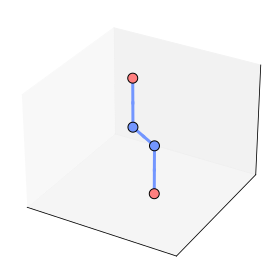

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

zx = gb.to_zx_graph()

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


stabilizer tests passed


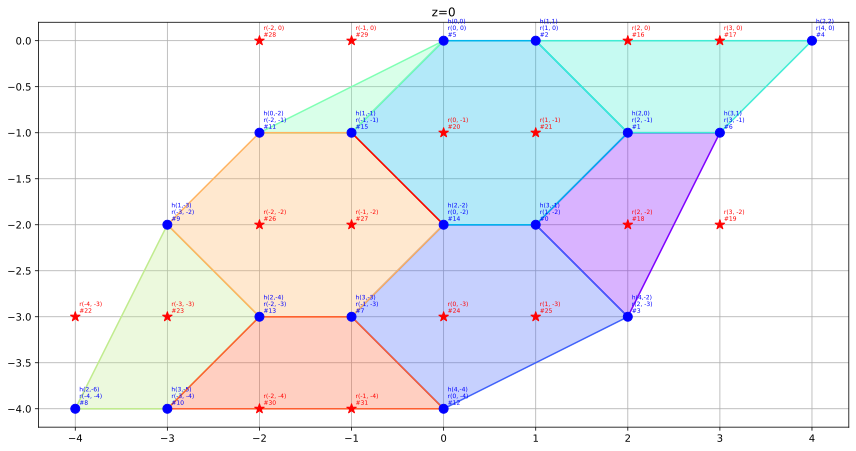

In [35]:
d=3
SE = se.SyndromeExtractionStimCC(gc, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 0
temp_utils.plot_mapping_full(mapping_full, z_temp)

In [41]:
d=3
rounds = d
p = 0.01

idx = 0
correlation_surfaces = gc.find_correlation_surfaces()
cs = correlation_surfaces[idx]

SE = se.SyndromeExtractionStimCC(gc, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = [cs]
)

dem = circuit.detector_error_model()


error = circuit.shortest_graphlike_error()
print(len(error))
errors = circuit.search_for_undetectable_logical_errors(
    dont_explore_detection_event_sets_with_size_above=d,
    dont_explore_edges_with_degree_above=2,
    dont_explore_edges_increasing_symptom_degree=True,
)
d = len(errors)
print(d)

print(error)

stabilizer tests passed
========================z=-1=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1), PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=6)]
lst [1, 16]
lst [6, 17]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=-2, z=0), rect=(2, -3), label=3)]
lst [3, 18]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=3, y=-1, z=0), rect=(1, -2), label=0)]
lst [0, 21]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=1, y=1, z=0), rect=(1, 0), label=2), PositionEntry(hex=Position3DHex(x=2, y=2, z=0), rect=(4, 0), label=4)]
lst [2, 16]
lst [4, 17]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=3, y=-1, z=0), rect=(1, -2), label=0)]
lst [0, 18]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1)]
lst [1, 21]
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex

In [37]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_tele_C_d{d}.svg", "w") as f:
    f.write(str(svg))

In [38]:
print(circuit.to_crumble_url())

https://algassert.com/crumble#circuit=Q(5,2)0;Q(6,3)1;Q(5,4)2;Q(6,1)3;Q(8,4)4;Q(4,4)5;Q(7,3)6;Q(3,1)7;Q(0,0)8;Q(1,2)9;Q(1,0)10;Q(2,3)11;Q(4,0)12;Q(2,1)13;Q(4,2)14;Q(3,3)15;Q(6,4)16;Q(7,4)17;Q(6,2)18;Q(7,2)19;Q(4,3)20;Q(5,3)21;Q(0,1)22;Q(1,1)23;Q(4,1)24;Q(5,1)25;Q(2,2)26;Q(3,2)27;Q(2,4)28;Q(3,4)29;Q(2,0)30;Q(3,0)31;R_0_1_2_3_4_5_6;X_ERROR(0.01)0_1_2_3_4_5_6;RX_16;Z_ERROR(0.01)16;R_17;X_ERROR(0.01)17;RX_18;Z_ERROR(0.01)18;R_19;X_ERROR(0.01)19;RX_20;Z_ERROR(0.01)20;R_21;X_ERROR(0.01)21;TICK;CX_16_17;DEPOLARIZE2(0.01)16_17;CX_18_19;DEPOLARIZE2(0.01)18_19;CX_20_21;DEPOLARIZE2(0.01)20_21;DEPOLARIZE1(0.01)0_1_2_3_4_5_6;TICK;CX_1_16;DEPOLARIZE2(0.01)1_16;CX_6_17;DEPOLARIZE2(0.01)6_17;CX_3_18;DEPOLARIZE2(0.01)3_18;CX_0_21;DEPOLARIZE2(0.01)0_21;DEPOLARIZE1(0.01)2_4_5_19_20;TICK;CX_2_16;DEPOLARIZE2(0.01)2_16;CX_4_17;DEPOLARIZE2(0.01)4_17;CX_0_18;DEPOLARIZE2(0.01)0_18;CX_1_21;DEPOLARIZE2(0.01)1_21;DEPOLARIZE1(0.01)3_5_6_19_20;TICK;CX_1_18;DEPOLARIZE2(0.01)1_18;CX_6_19;DEPOLARIZE2(0.01)6_19;CX_5_20

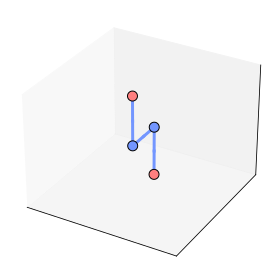

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

zx = gc.to_zx_graph()

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


## CNOT in different alignments

just make sure that this is debugged too

In [42]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [43]:
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(1,1,0), "ZN", "control-int"),
    (Position3DHex(1,1,1), "NN", ""),
    (Position3DHex(1,1,2), "NN", ""),
    (Position3DHex(1,1,3), "NZ", "control-out"),

    (Position3DHex(2,0,1), "ZN", ""),
    (Position3DHex(2,0,2), "NX", ""),

    (Position3DHex(3,1,0), "ZN", "target-in"),
    (Position3DHex(3,1,1), "NN", ""),
    (Position3DHex(3,1,2), "NN", ""),
    (Position3DHex(3,1,3), "NZ", "target-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#c temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

g.view_as_html()

In [44]:
zx = g.to_zx_graph()
correlation_surfaces = g.find_correlation_surfaces()
print("len correlation surfaces", len(correlation_surfaces))

idx = 1

cs = correlation_surfaces[idx]


len correlation surfaces 2


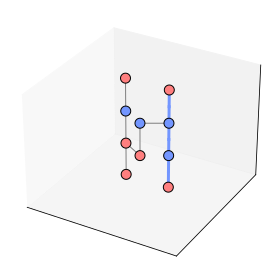

In [45]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


stabilizer tests passed
stabilizer tests passed


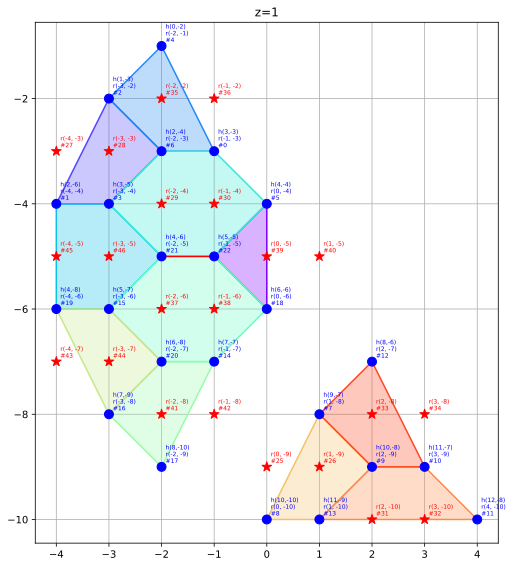

In [46]:
d=3
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 1
temp_utils.plot_mapping_full(mapping_full, z_temp)

In [47]:
d=3
rounds = d
p = 0.00


SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = [cs]
)

stabilizer tests passed
stabilizer tests passed
========================z=0=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=-6, z=0), rect=(-4, -4), label=1), PositionEntry(hex=Position3DHex(x=3, y=-5, z=0), rect=(-3, -4), label=3)]
lst [1, 27]
lst [3, 28]
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=-4, z=0), rect=(-2, -3), label=6), PositionEntry(hex=Position3DHex(x=3, y=-3, z=0), rect=(-1, -3), label=0)]
lst [6, 35]
lst [0, 36]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=10, y=-10, z=0), rect=(0, -10), label=8), PositionEntry(hex=Position3DHex(x=11, y=-9, z=0), rect=(1, -10), label=13)]
lst [8, 25]
lst [13, 26]
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=10, y=-8, z=0), rect=(2, -9), label=9), PositionEntry(hex=Position3DHex(x=11, y=-7, z=0), rect=(3, -9), label=10)]
lst [9, 33]
lst [10, 34]
stabtype XZ, Z stab
entries 

In [48]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_CNOT_d{d}.svg", "w") as f:
    f.write(str(svg))

In [49]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
Detectors that fired: []


In [169]:
dem = circuit.detector_error_model()

len(circuit.shortest_graphlike_error())

ValueError: Failed to find any graphlike logical errors.
    WARNING: NO ERRORS. The circuit or detector error model didn't include any errors, making it vacuously impossible to find a logical error.

In [170]:
circuit

stim.Circuit('''
    QUBIT_COORDS(3, 7) 0
    QUBIT_COORDS(0, 6) 1
    QUBIT_COORDS(1, 8) 2
    QUBIT_COORDS(1, 6) 3
    QUBIT_COORDS(2, 9) 4
    QUBIT_COORDS(4, 6) 5
    QUBIT_COORDS(2, 7) 6
    QUBIT_COORDS(5, 2) 7
    QUBIT_COORDS(4, 0) 8
    QUBIT_COORDS(6, 1) 9
    QUBIT_COORDS(7, 1) 10
    QUBIT_COORDS(8, 0) 11
    QUBIT_COORDS(6, 3) 12
    QUBIT_COORDS(5, 0) 13
    QUBIT_COORDS(3, 3) 14
    QUBIT_COORDS(1, 4) 15
    QUBIT_COORDS(1, 2) 16
    QUBIT_COORDS(2, 1) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(0, 4) 19
    QUBIT_COORDS(2, 3) 20
    QUBIT_COORDS(2, 5) 21
    QUBIT_COORDS(3, 5) 22
    QUBIT_COORDS(4, 2) 23
    QUBIT_COORDS(3, 1) 24
    QUBIT_COORDS(4, 1) 25
    QUBIT_COORDS(5, 1) 26
    QUBIT_COORDS(0, 7) 27
    QUBIT_COORDS(1, 7) 28
    QUBIT_COORDS(2, 6) 29
    QUBIT_COORDS(3, 6) 30
    QUBIT_COORDS(6, 0) 31
    QUBIT_COORDS(7, 0) 32
    QUBIT_COORDS(6, 2) 33
    QUBIT_COORDS(7, 2) 34
    QUBIT_COORDS(2, 8) 35
    QUBIT_COORDS(3, 8) 36
    QUBIT_COORDS(2, 4) 37
    Q

## Sanity Check Spatial Hadamard

In [1]:
import stim

def to_pauli_string(stab, n):
    """Convert a list of (pauli, qubit_index) tuples to a stim.PauliString of length n."""
    chars = ["I"] * n
    for pauli, idx in stab:
        chars[idx] = pauli
    return stim.PauliString("".join(chars))

def from_pauli_string(pauli):
    """Convert a stim.PauliString back to (sign, list of (pauli, qubit_index)) tuples."""
    sign = "" if pauli.sign == 1 else "-"
    xs, zs = pauli.to_numpy()
    tuples = []
    for i, (x, z) in enumerate(zip(xs, zs)):
        if x and z:
            tuples.append(("Y", i))
        elif x:
            tuples.append(("X", i))
        elif z:
            tuples.append(("Z", i))
    return sign, tuples

def is_logical(candidate, stabilizers, tableau):
    """Check whether `candidate` is a logical operator (commutes with all stabilizers,
    but is not itself in the stabilizer group)."""
    n = len(tableau)
    k = n - len(stabilizers)

    commutes_with_all = all(candidate.commutes(s) for s in stabilizers)

    inv = tableau.inverse()
    conjugated = inv(candidate)
    xs, zs = conjugated.to_numpy()
    is_pure_stabilizer = not (xs[n-k:].any() or zs[n-k:].any())

    return commutes_with_all and not is_pure_stabilizer

def multiply_stabilizers(stab_list, n):
    """Multiply a list of stabilizers (each given as tuple form) and return the
    product in human-readable tuple form."""
    result = stim.PauliString(n)  # identity
    for stab in stab_list:
        result = result * to_pauli_string(stab, n)
    sign, tuples = from_pauli_string(result)
    return sign, tuples

n = 7+7+2  # number of qubits

# Steane code stabilizers given as (Pauli, qubit_index) tuples
stab_tuples = [
    [("X", 0), ("X", 1), ("X", 4), ("X", 5)],
    [("Z", 0), ("Z", 1), ("Z", 4), ("Z", 5)],

    [("X", 1), ("X", 2), ("X", 3), ("X", 4)],
    [("Z", 1), ("Z", 2), ("Z", 3), ("Z", 4)],

    [("X", 3), ("X", 4), ("X", 5), ("X", 6), ("X", 14), ("X", 15)],
    [("Z", 3), ("Z", 4), ("Z", 5), ("Z", 6), ("Z", 14), ("Z", 15)],

    [("X", 8), ("X", 9), ("X", 10), ("X", 12)],
    [("Z", 8), ("Z", 9), ("Z", 10), ("Z", 12)],

    [("X", 10), ("X", 11), ("X", 12), ("X", 13)],
    [("Z", 10), ("Z", 11), ("Z", 12), ("Z", 13)],

    #mixed and single type, or double type
    [("X", 14), ("X", 15)],

    [("X", 2), ("X", 3), ("X", 15), ("Z", 8), ("Z", 9)],

    [("X", 6), ("X", 14), ("Z", 7)],

    [("X", 14), ("X", 15), ("Z", 7), ("Z", 8), ("Z", 12), ("Z", 13)],
    [("Z", 14), ("Z", 15), ("X", 7), ("X", 8), ("X", 12), ("X", 13)],

]

stabilizers = [to_pauli_string(s, n) for s in stab_tuples]
tableau = stim.Tableau.from_stabilizers(stabilizers, allow_redundant=False, allow_underconstrained=True)

k = n - len(stabilizers)
print(f"n={n}, k={k}\n")

for i in range(k):
    for label, op in [(f"X_L{i}", tableau.x_output(n-k+i)), (f"Z_L{i}", tableau.z_output(n-k+i))]:
        sign, tuples = from_pauli_string(op)
        print(f"{label}: {sign}{tuples}")

# --- check a candidate logical operator ---
candidate_tuples = [("Z",1), ("Z",3), ("Z",5), ("X", 8), ("X", 10), ("X", 13)]
candidate = to_pauli_string(candidate_tuples, n)
print(f"\nCandidate {candidate_tuples} is a logical operator: {is_logical(candidate, stabilizers, tableau)}")

#--- check stabilizer product
subset = [
    [("X", 1), ("X", 2), ("X", 3), ("X", 4)],
    [("X", 3), ("X", 4), ("X", 5), ("X", 6), ("X", 14), ("X", 15)],
    [("X", 14), ("X", 15)],
    [("X", 2), ("X", 3), ("X", 15), ("Z", 8), ("Z", 9)],
    [("X", 6), ("X", 14), ("Z", 7)],
    [("X", 14), ("X", 15), ("Z", 7), ("Z", 8), ("Z", 12), ("Z", 13)],
    [("Z", 8), ("Z", 9), ("Z", 10), ("Z", 12)],

]
sign, tuples = multiply_stabilizers(subset, n)
print(f"Product of {subset}:")
print(f"= {sign}{tuples}")

n=16, k=1

X_L0: [('X', 1), ('X', 3), ('X', 5)]
Z_L0: [('Z', 2), ('Z', 4), ('Z', 5), ('X', 9), ('X', 12), ('X', 13)]

Candidate [('Z', 1), ('Z', 3), ('Z', 5), ('X', 8), ('X', 10), ('X', 13)] is a logical operator: True
Product of [[('X', 1), ('X', 2), ('X', 3), ('X', 4)], [('X', 3), ('X', 4), ('X', 5), ('X', 6), ('X', 14), ('X', 15)], [('X', 14), ('X', 15)], [('X', 2), ('X', 3), ('X', 15), ('Z', 8), ('Z', 9)], [('X', 6), ('X', 14), ('Z', 7)], [('X', 14), ('X', 15), ('Z', 7), ('Z', 8), ('Z', 12), ('Z', 13)], [('Z', 8), ('Z', 9), ('Z', 10), ('Z', 12)]]:
= [('X', 1), ('X', 3), ('X', 5), ('Z', 8), ('Z', 10), ('Z', 13)]


## Sanity Check S gate

In [6]:
n = 7+7+2  # number of qubits

# Steane code stabilizers given as (Pauli, qubit_index) tuples
stab_tuples = [
    [("X", 0), ("X", 1), ("X", 4), ("X", 5)],
    [("Z", 0), ("Z", 1), ("Z", 4), ("Z", 5)],

    [("X", 1), ("X", 2), ("X", 3), ("X", 4)],
    [("Z", 1), ("Z", 2), ("Z", 3), ("Z", 4)],

    [("X", 3), ("X", 4), ("X", 5), ("X", 6), ("X", 14), ("X", 15)],
    [("Z", 3), ("Z", 4), ("Z", 5), ("Z", 6), ("Z", 14), ("Z", 15)],

    [("X", 8), ("X", 9), ("X", 10), ("X", 12)],
    [("Z", 8), ("Z", 9), ("Z", 10), ("Z", 12)],

    [("X", 10), ("X", 11), ("X", 12), ("X", 13)],
    [("Z", 10), ("Z", 11), ("Z", 12), ("Z", 13)],

    #mixed and single type, or double type
    [("X", 14), ("X", 15)],

    [("X", 2), ("X", 3), ("X", 15), ("Y", 8), ("Y", 9)],

    [("X", 6), ("X", 14), ("Y", 7)],

    [("X", 14), ("X", 15), ("Y", 7), ("Y", 8), ("Y", 12), ("Y", 13)],
    [("Z", 14), ("Z", 15), ("Z", 7), ("Z", 8), ("Z", 12), ("Z", 13)],

]

stabilizers = [to_pauli_string(s, n) for s in stab_tuples]
tableau = stim.Tableau.from_stabilizers(stabilizers, allow_redundant=False, allow_underconstrained=True)

k = n - len(stabilizers)
print(f"n={n}, k={k}\n")

for i in range(k):
    for label, op in [(f"X_L{i}", tableau.x_output(n-k+i)), (f"Z_L{i}", tableau.z_output(n-k+i))]:
        sign, tuples = from_pauli_string(op)
        print(f"{label}: {sign}{tuples}")

# --- check a candidate logical operator ---
candidate_tuples = [("Z",1), ("Z",3), ("Z",5), ("X", 8), ("X", 10), ("X", 13)]
candidate = to_pauli_string(candidate_tuples, n)
print(f"\nCandidate {candidate_tuples} is a logical operator: {is_logical(candidate, stabilizers, tableau)}")

#--- check stabilizer product
subset = [  
    [("X", 1), ("X", 2), ("X", 3), ("X", 4)],
    [("X", 3), ("X", 4), ("X", 5), ("X", 6), ("X", 14), ("X", 15)],
    [("X", 14), ("X", 15)],
    [("X", 2), ("X", 3), ("X", 15), ("Y", 8), ("Y", 9)],
    [("X", 6), ("X", 14), ("Y", 7)],
    [("X", 14), ("X", 15), ("Y", 7), ("Y", 8), ("Y", 12), ("Y", 13)],
    [("Y", 8), ("Y", 9), ("Y", 10), ("Y", 12)],

]
sign, tuples = multiply_stabilizers(subset, n)
print(f"Product of {subset}:")
print(f"= {sign}{tuples}")

n=16, k=1

X_L0: [('X', 1), ('X', 3), ('X', 5)]
Z_L0: -[('Z', 2), ('Z', 4), ('Z', 5), ('X', 9), ('X', 12), ('X', 13)]

Candidate [('Z', 1), ('Z', 3), ('Z', 5), ('X', 8), ('X', 10), ('X', 13)] is a logical operator: True
Product of [[('X', 1), ('X', 2), ('X', 3), ('X', 4)], [('X', 3), ('X', 4), ('X', 5), ('X', 6), ('X', 14), ('X', 15)], [('X', 14), ('X', 15)], [('X', 2), ('X', 3), ('X', 15), ('Y', 8), ('Y', 9)], [('X', 6), ('X', 14), ('Y', 7)], [('X', 14), ('X', 15), ('Y', 7), ('Y', 8), ('Y', 12), ('Y', 13)], [('Y', 8), ('Y', 9), ('Y', 10), ('Y', 12)]]:
= [('X', 1), ('X', 3), ('X', 5), ('Y', 8), ('Y', 10), ('Y', 13)]


# understand Hadamard on single patch but on two

In [28]:
import stim
import numpy as np

def to_pauli_string(stab, n):
    chars = ["I"] * n
    for pauli, idx in stab:
        chars[idx] = pauli
    return stim.PauliString("".join(chars))

def from_pauli_string(pauli):
    sign = "" if pauli.sign == 1 else "-"
    xs, zs = pauli.to_numpy()
    tuples = []
    for i, (x, z) in enumerate(zip(xs, zs)):
        if x and z:
            tuples.append(("Y", i))
        elif x:
            tuples.append(("X", i))
        elif z:
            tuples.append(("Z", i))
    return sign, tuples

def pauli_to_symplectic(pauli, n):
    xs, zs = pauli.to_numpy()
    return np.concatenate([xs.astype(int), zs.astype(int)])

def gf2_rank(matrix):
    """Rank of a binary matrix over GF(2)."""
    m = matrix.copy() % 2
    rows, cols = m.shape
    rank = 0
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if m[r, col] == 1:
                pivot = r
                break
        if pivot is None:
            continue
        m[[rank, pivot]] = m[[pivot, rank]]
        for r in range(rows):
            if r != rank and m[r, col] == 1:
                m[r] = (m[r] + m[rank]) % 2
        rank += 1
    return rank

def is_in_stabilizer_group(pauli, stabilizers, n):
    """Check (ignoring sign) if `pauli` is in the group generated by `stabilizers`."""
    stab_matrix = np.array([pauli_to_symplectic(s, n) for s in stabilizers])
    pauli_vec = pauli_to_symplectic(pauli, n)
    rank_without = gf2_rank(stab_matrix)
    rank_with = gf2_rank(np.vstack([stab_matrix, pauli_vec]))
    return rank_with == rank_without

def hadamard_tableau(qubits, n):
    """Build the tableau for H applied to the given qubits, identity elsewhere."""
    t = stim.Tableau(n)
    h = stim.Tableau.from_named_gate("H")
    for q in qubits:
        t.append(h, [q])
    return t

def check_clifford_preserves_stabilizers(clifford_tableau, stabilizers, n):
    """For each stabilizer, conjugate by the Clifford and check if the result
    is still in the stabilizer group. Returns True overall iff the Clifford
    preserves the stabilizer group as a set."""
    all_preserved = True
    for s in stabilizers:
        conjugated = clifford_tableau(s)
        in_group = is_in_stabilizer_group(conjugated, stabilizers, n)
        sign, tuples = from_pauli_string(conjugated)
        print(f"  {from_pauli_string(s)[1]} -> {sign}{tuples}   in stabilizer group: {in_group}")
        all_preserved &= in_group
    return all_preserved


n = 7+7+2  # number of qubits

# Steane code stabilizers given as (Pauli, qubit_index) tuples
stab_tuples = [
    [("X", 0), ("X", 1), ("X", 4), ("X", 5)],
    [("Z", 0), ("Z", 1), ("Z", 4), ("Z", 5)],

    [("X", 1), ("X", 2), ("X", 3), ("X", 4)],
    [("Z", 1), ("Z", 2), ("Z", 3), ("Z", 4)],

    [("X", 3), ("X", 4), ("X", 5), ("X", 6), ("X", 14), ("X", 15)],
    [("Z", 3), ("Z", 4), ("Z", 5), ("Z", 6), ("Z", 14), ("Z", 15)],

    [("X", 8), ("X", 9), ("X", 10), ("X", 12)],
    [("Z", 8), ("Z", 9), ("Z", 10), ("Z", 12)],

    [("X", 10), ("X", 11), ("X", 12), ("X", 13)],
    [("Z", 10), ("Z", 11), ("Z", 12), ("Z", 13)],

    #mixed and single type, or double type
    [("X", 14), ("X", 15)],

    [("X", 2), ("X", 3), ("X", 15), ("X", 8), ("X", 9)],

    [("X", 6), ("X", 14), ("X", 7)],

    [("X", 14), ("X", 15), ("X", 7), ("X", 8), ("X", 12), ("X", 13)],
    [("Z", 14), ("Z", 15), ("Z", 7), ("Z", 8), ("Z", 12), ("Z", 13)],

]
stabilizers = [to_pauli_string(s, n) for s in stab_tuples]

print("Transversal H on all 7 qubits:")
H_all = hadamard_tableau(range(7), n)
print("All preserved:", check_clifford_preserves_stabilizers(H_all, stabilizers, n))


Transversal H on all 7 qubits:
  [('X', 0), ('X', 1), ('X', 4), ('X', 5)] -> [('Z', 0), ('Z', 1), ('Z', 4), ('Z', 5)]   in stabilizer group: True
  [('Z', 0), ('Z', 1), ('Z', 4), ('Z', 5)] -> [('X', 0), ('X', 1), ('X', 4), ('X', 5)]   in stabilizer group: True
  [('X', 1), ('X', 2), ('X', 3), ('X', 4)] -> [('Z', 1), ('Z', 2), ('Z', 3), ('Z', 4)]   in stabilizer group: True
  [('Z', 1), ('Z', 2), ('Z', 3), ('Z', 4)] -> [('X', 1), ('X', 2), ('X', 3), ('X', 4)]   in stabilizer group: True
  [('X', 3), ('X', 4), ('X', 5), ('X', 6), ('X', 14), ('X', 15)] -> [('Z', 3), ('Z', 4), ('Z', 5), ('Z', 6), ('X', 14), ('X', 15)]   in stabilizer group: False
  [('Z', 3), ('Z', 4), ('Z', 5), ('Z', 6), ('Z', 14), ('Z', 15)] -> [('X', 3), ('X', 4), ('X', 5), ('X', 6), ('Z', 14), ('Z', 15)]   in stabilizer group: False
  [('X', 8), ('X', 9), ('X', 10), ('X', 12)] -> [('X', 8), ('X', 9), ('X', 10), ('X', 12)]   in stabilizer group: True
  [('Z', 8), ('Z', 9), ('Z', 10), ('Z', 12)] -> [('Z', 8), ('Z', 9), (

In [30]:
#steane code as sanity check
n = 7
stab_tuples = [
    [("X",0), ("X",1), ("X",4), ("X",5)],
    [("X",0), ("X",2), ("X",4), ("X",6)],
    [("X",3), ("X",4), ("X",5), ("X",6)],
    [("Z",0), ("Z",1), ("Z",4), ("Z",5)],
    [("Z",0), ("Z",2), ("Z",4), ("Z",6)],
    [("Z",3), ("Z",4), ("Z",5), ("Z",6)],
]
stabilizers = [to_pauli_string(s, n) for s in stab_tuples]

print("Transversal H on all 7 qubits:")
H_all = hadamard_tableau(range(n), n)
print("All preserved:", check_clifford_preserves_stabilizers(H_all, stabilizers, n))

print("\nH on qubit 0 only:")
H_q0 = hadamard_tableau([0], n)
print("All preserved:", check_clifford_preserves_stabilizers(H_q0, stabilizers, n))

Transversal H on all 7 qubits:
  [('X', 0), ('X', 1), ('X', 4), ('X', 5)] -> [('Z', 0), ('Z', 1), ('Z', 4), ('Z', 5)]   in stabilizer group: True
  [('X', 0), ('X', 2), ('X', 4), ('X', 6)] -> [('Z', 0), ('Z', 2), ('Z', 4), ('Z', 6)]   in stabilizer group: True
  [('X', 3), ('X', 4), ('X', 5), ('X', 6)] -> [('Z', 3), ('Z', 4), ('Z', 5), ('Z', 6)]   in stabilizer group: True
  [('Z', 0), ('Z', 1), ('Z', 4), ('Z', 5)] -> [('X', 0), ('X', 1), ('X', 4), ('X', 5)]   in stabilizer group: True
  [('Z', 0), ('Z', 2), ('Z', 4), ('Z', 6)] -> [('X', 0), ('X', 2), ('X', 4), ('X', 6)]   in stabilizer group: True
  [('Z', 3), ('Z', 4), ('Z', 5), ('Z', 6)] -> [('X', 3), ('X', 4), ('X', 5), ('X', 6)]   in stabilizer group: True
All preserved: True

H on qubit 0 only:
  [('X', 0), ('X', 1), ('X', 4), ('X', 5)] -> [('Z', 0), ('X', 1), ('X', 4), ('X', 5)]   in stabilizer group: False
  [('X', 0), ('X', 2), ('X', 4), ('X', 6)] -> [('Z', 0), ('X', 2), ('X', 4), ('X', 6)]   in stabilizer group: False
  [('X'